In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [5]:
root = '/gpfs01/berens/data/data/medical_imaging/Dermoscopy/ISIC_2018/Task3/'

In [6]:
train = pd.read_csv(os.path.join(root, 'init_csv/Training_GroundTruth.csv'))
print(train.shape)
train.head()

(10015, 8)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
class_cols = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
train['label'] = train[class_cols].values.argmax(axis=1)

# keep a mapping for later (confusion matrices, reports, etc.)
label_map = {i: c for i, c in enumerate(class_cols)}

print(label_map)
train.head(3)

{0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'AKIEC', 4: 'BKL', 5: 'DF', 6: 'VASC'}


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,label
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1


In [12]:
#train.to_csv(os.path.join(root, 'Training_GroundTruth_v2.csv'), index=False)
df_train = pd.read_csv(os.path.join(root, 'Training_GroundTruth_v2.csv'))

In [13]:
val = pd.read_csv(os.path.join(root, 'init_csv/Validation_GroundTruth.csv'))

val['label'] = val[class_cols].values.argmax(axis=1)

print(val.shape)
val.head()

(193, 9)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,label
0,ISIC_0034321,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
1,ISIC_0034322,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
2,ISIC_0034323,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
3,ISIC_0034324,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
4,ISIC_0034325,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1


In [16]:
#val.to_csv(os.path.join(root, 'Validation_GroundTruth_v2.csv'), index=False)
df_val = pd.read_csv(os.path.join(root, 'Validation_GroundTruth_v2.csv'))
df_val.label.value_counts().sort_index()

label
0     21
1    123
2     15
3      8
4     22
5      1
6      3
Name: count, dtype: int64

In [17]:
test = pd.read_csv(os.path.join(root, 'init_csv/Test_GroundTruth.csv'))

test['label'] = test[class_cols].values.argmax(axis=1)

print(test.shape)
test.head()

(1512, 9)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,label
0,ISIC_0034524,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
1,ISIC_0034525,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
2,ISIC_0034526,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4
3,ISIC_0034527,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
4,ISIC_0034528,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1


In [19]:
#test.to_csv(os.path.join(root, 'Test_GroundTruth_v2.csv'), index=False)
df_test = pd.read_csv(os.path.join(root, 'Test_GroundTruth_v2.csv'))
df_val.label.value_counts().sort_index()

label
0     21
1    123
2     15
3      8
4     22
5      1
6      3
Name: count, dtype: int64

## Class weights for the loss

In [51]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(df_train['label']), y=df_train['label'])
class_weights

array([ 1.28545758,  0.21338021,  2.78349083,  4.37527304,  1.30183284,
       12.44099379, 10.07545272])

In [20]:
# Uniform
class_weights = compute_class_weight(class_weight=None, classes=np.unique(df_train['label']), y=df_train['label'])
class_weights

array([1., 1., 1., 1., 1., 1., 1.])

## Weighted sampler (alternative to loss weighting)
Instead of weighting the loss, the sampling probability can be weighted so each batch sees a more balanced mix of classes. 

In [22]:
class_counts = df_train['label'].value_counts().sort_index().values
print('Class count: ', class_counts)

class_weights = 1.0 / class_counts  # inverse frequency
#print(class_weights.sum())
print('Class weight: ', class_weights)

# per-sample weight = weight of its class
sample_weights = df_train['label'].map(lambda c: class_weights[c]).values
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # required — lets minority classes be resampled
)

Class count:  [1113 6705  514  327 1099  115  142]
Class weight:  [0.00089847 0.00014914 0.00194553 0.0030581  0.00090992 0.00869565
 0.00704225]


## Dataset

In [23]:
class ISICDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'] + '.jpg')
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = int(row['label'])
        return image, label

## Transforms
Transform pipeline for dermoscopic images
- **Rotation/flips are safe and valuable**: unlike natural images, skin lesions have no canonical orientation, so full 360° rotation and both horizontal/vertical flips are valid augmentations (not just horizontal flip like ImageNet-style pipelines).
- **Color jitter should be mild**: dermoscopic diagnosis relies on subtle color cues (pigment networks, blue-white veils, etc.), so aggressive hue/saturation jitter can destroy diagnostically relevant signal. Keep it subtle.
- **Avoid strong random crops**: lesions are often centered and cropping too aggressively risks cutting off the lesion border, which is itself diagnostic (irregular borders are a melanoma indicator). Mild scale/crop only.
- **Normalization**: use ImageNet stats if you're fine-tuning a pretrained backbone (ResNet, EfficientNet, etc., which is standard here); compute dataset-specific mean/std only if training from scratch.

In [24]:
IMG_SIZE = (224, 224)  # adjust to your backbone's expected input

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),  # lesions have no canonical orientation
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),  # mild crop only
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                          std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

## Dataloader

In [27]:
img_dir = os.path.join(root, 'Training_Input')

train_loader = DataLoader(
    ISICDataset(df_train, img_dir, transform=train_transform),
    batch_size=32,
    sampler=sampler,   # replaces shuffle=True
    num_workers=4
)

val_loader = DataLoader(
    ISICDataset(df_val, img_dir, transform=val_transform),
    batch_size=32,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    ISICDataset(df_test, img_dir, transform=val_transform),
    batch_size=32,
    shuffle=True,
    num_workers=4
)

print(len(train_loader), len(val_loader), len(test_loader))

313 7 48


## Sanity-check script — visualize a batch after augmentation
Since the tensors are normalized, unnormalized is needed before displaying, or the images will look washed out/color-shifted.

In [25]:
def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean


def visualize_batch(loader, label_map, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 8))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        img = denormalize(images[i], mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()  # CHW -> HWC
        ax.imshow(img)
        ax.set_title(label_map[labels[i].item()], fontsize=16, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

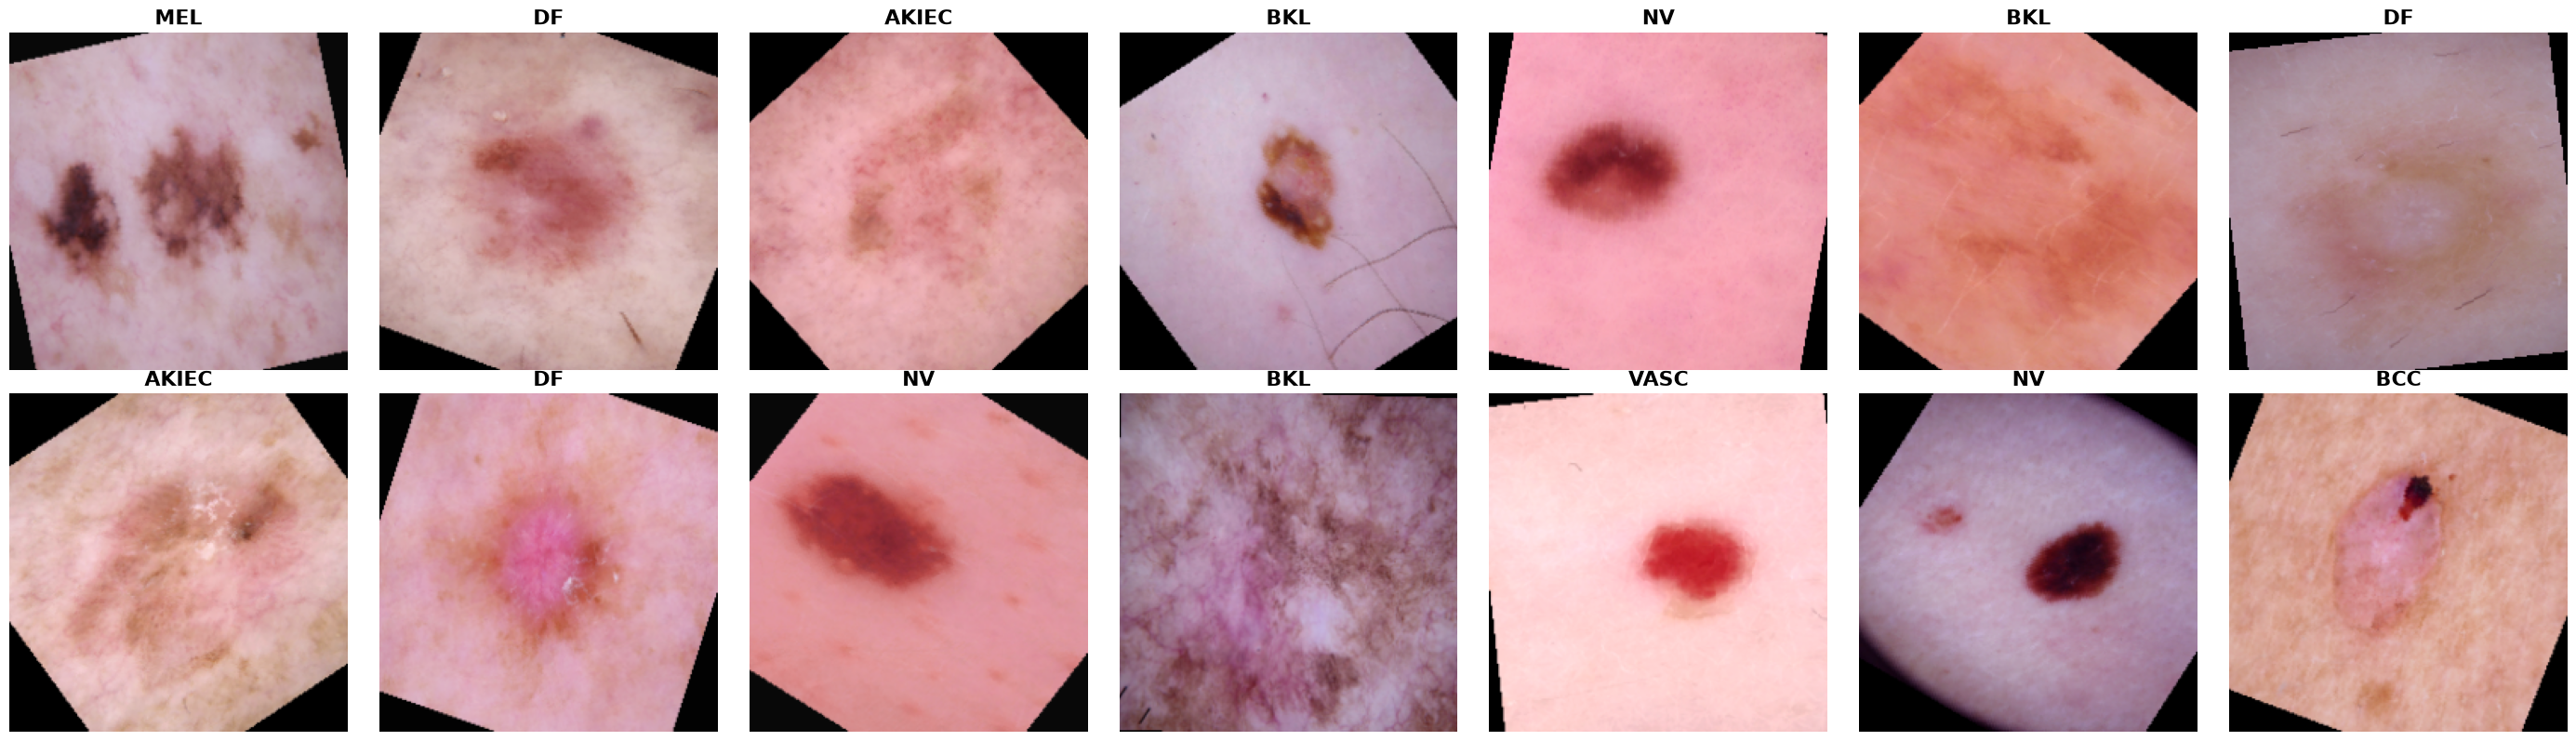

In [29]:
visualize_batch(train_loader, label_map, n=14)

## What else?